In [3]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [5]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

individual_test_thai_call_center_asr_path = kagglehub.competition_download('individual-test-thai-call-center-asr')

print('Data source import complete.')

100%|██████████| 2.30G/2.30G [02:10<00:00, 18.9MB/s]

Extracting files...


Data source import complete.


# [Super AI Engineer Season 6] Hackathon Week 6
## 5 Domains Hackathon: Thai Call Center ASR

**Super AI Engineer Season 6 - Level 2 Hackathon**  
- Dataset: Thai Call Center ASR
- Notebook: Whisper-style ASR inference pipeline
- จัดทำโดย: 600425-วิศิษฐ์

---
### Notebook Outline
1. Setup & Imports  
2. Data Loading & Initial Inspection  
3. Audio Metadata Exploration  
4. Audio Preview  
5. Data Preprocessing  
6. Text Post-Processing  
7. Model Preparation  
8. Model Inference  
9. Prediction & Submission Generation  
10. Submission Safety Check

# 1. Setup & Imports
### 1.1 Prepare libraries, paths, and runtime settings

Set all runtime controls in one place so model choice, dataset path, and output path can be adjusted quickly before inference.

In [6]:
# ถ้า Kaggle environment ยังขาด dependency และอนุญาตให้ใช้ internet ให้เปิดบรรทัดนี้ก่อนรัน notebook
# !pip -q install -U transformers accelerate soundfile librosa jiwer

import os
import re
import json
import wave
import random
import string
import unicodedata
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import Audio, display

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_SLUG = 'individual-test-thai-call-center-asr'
LOCAL_DATA_DIR = Path('Level 2/Hackathon 9_5 Domains Hackathon/Thai Call Center ASR') / DATASET_SLUG

if 'individual_test_thai_call_center_asr_path' in globals():
    khub_path = Path(individual_test_thai_call_center_asr_path)
else:
    try:
        import kagglehub
        khub_path = Path(kagglehub.competition_download('individual-test-thai-call-center-asr'))
    except Exception:
        khub_path = Path('__not_found__')

DATA_DIR_CANDIDATES = [
    Path('/kaggle/input/competitions') / DATASET_SLUG,
    Path('/kaggle/input') / DATASET_SLUG,
    LOCAL_DATA_DIR,
    Path(DATASET_SLUG),
    Path('.'),
    khub_path,
]


def find_dataset_dir(candidates):
    for candidate in candidates:
        if (candidate / 'sample_submission.csv').exists():
            return candidate
    raise FileNotFoundError('Cannot find sample_submission.csv from DATA_DIR_CANDIDATES')


DATA_DIR = find_dataset_dir(DATA_DIR_CANDIDATES)
KAGGLE_MODE = Path('/kaggle/input').exists()
WORK_DIR = Path('/kaggle/working') if KAGGLE_MODE else Path('Level 2/Hackathon 9_5 Domains Hackathon/Thai Call Center ASR')
WORK_DIR.mkdir(parents=True, exist_ok=True)

SUBMISSION_PATH = WORK_DIR / 'submission.csv'
FORMAT_CHECK_SUBMISSION_PATH = WORK_DIR / 'submission_format_check.csv'
REPRESENTATIVE_CACHE_PATH = WORK_DIR / 'asr_representative_predictions.csv'
FULL_PREDICTION_CACHE_PATH = WORK_DIR / 'asr_full_predictions.csv'

# Default สำหรับ Kaggle: รัน ASR จริง ถ้าจะ smoke test local ให้ set env RUN_ASR=0 ก่อน execute
RUN_ASR = os.environ.get('RUN_ASR', '1') == '1'
REPRESENTATIVE_ONLY = True
REPRESENTATIVE_LIMIT = None  # ตั้งเป็นเลขเล็ก ๆ เช่น 20 เพื่อ smoke test ก่อนรันจริง
BATCH_SIZE = int(os.environ.get('ASR_BATCH_SIZE', '16'))  # เพิ่ม Batch Size สำหรับ A100
SAVE_EVERY = 25

# ถ้า Kaggle ไม่มี internet ให้ Add model weights แล้วตั้ง ASR_MODEL_DIR เป็น path ของ model folder
ASR_MODEL_DIR = os.environ.get('ASR_MODEL_DIR', '').strip()
# เปลี่ยนมาใช้โมเดลใหญ่สุดเพื่อความแม่นยำ
ASR_MODEL_NAME = os.environ.get('ASR_MODEL_NAME', 'openai/whisper-large-v3')
FALLBACK_MODEL_NAME = os.environ.get('ASR_FALLBACK_MODEL_NAME', 'openai/whisper-large-v3-turbo')
MODEL_SOURCE = ASR_MODEL_DIR if ASR_MODEL_DIR else ASR_MODEL_NAME

# อย่าใส่ benchmark target ในโค้ด cell นี้ ให้ใช้ validation/submission score จาก Kaggle เป็นตัวตัดสิน
DEFAULT_FALLBACK_TEXT = 'ค่ะ'

print('KAGGLE_MODE:', KAGGLE_MODE)
print('DATA_DIR:', DATA_DIR.resolve())
print('WORK_DIR:', WORK_DIR.resolve())
print('SUBMISSION_PATH:', SUBMISSION_PATH)
print('RUN_ASR:', RUN_ASR)
print('REPRESENTATIVE_ONLY:', REPRESENTATIVE_ONLY)
print('MODEL_SOURCE:', MODEL_SOURCE)

KAGGLE_MODE: True
DATA_DIR: /root/.cache/kagglehub/competitions/individual-test-thai-call-center-asr
WORK_DIR: /kaggle/working
SUBMISSION_PATH: /kaggle/working/submission.csv
RUN_ASR: True
REPRESENTATIVE_ONLY: True
MODEL_SOURCE: openai/whisper-large-v3


# 2. Data Loading & Initial Inspection
### 2.1 Load sample submission and resolve audio paths

Use `sample_submission.csv` as the source of required ids, then build an audio lookup that works for both Kaggle and local folder layouts.

In [7]:
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv', dtype=str)

if sample_submission.shape[1] != 2:
    raise ValueError(f'sample_submission must have exactly 2 columns, found {sample_submission.columns.tolist()}')

ID_COL = 'file_name' if 'file_name' in sample_submission.columns else sample_submission.columns[0]
TEXT_COL = 'text' if 'text' in sample_submission.columns else sample_submission.columns[1]

sample_submission[ID_COL] = sample_submission[ID_COL].astype(str)
sample_submission[TEXT_COL] = sample_submission[TEXT_COL].fillna('').astype(str)

AUDIO_EXTENSIONS = ['.wav', '.flac', '.mp3', '.m4a']
audio_paths = []
for ext in AUDIO_EXTENSIONS:
    audio_paths.extend(DATA_DIR.rglob(f'*{ext}'))
    audio_paths.extend(DATA_DIR.rglob(f'*{ext.upper()}'))

audio_lookup = {path.name: path for path in audio_paths}
sample_submission['audio_path'] = sample_submission[ID_COL].map(audio_lookup)

print('Sample submission shape:', sample_submission.shape)
print('Columns:', list(sample_submission.columns))
print('ID_COL:', ID_COL)
print('TEXT_COL:', TEXT_COL)
print('Audio files found:', len(audio_lookup))
print('Missing audio rows:', sample_submission['audio_path'].isna().sum())
print('Duplicate ids:', sample_submission[ID_COL].duplicated().sum())
display(sample_submission.head(10))

if sample_submission['audio_path'].isna().any():
    missing = sample_submission.loc[sample_submission['audio_path'].isna(), ID_COL].head(10).tolist()
    raise FileNotFoundError(f'Missing audio files, examples: {missing}')

Sample submission shape: (6261, 3)
Columns: ['file_name', 'text', 'audio_path']
ID_COL: file_name
TEXT_COL: text
Audio files found: 6261
Missing audio rows: 0
Duplicate ids: 0


,file_name,text,audio_path
0,RSP_101_audio.wav,,/root/.cache/kagglehub/competitions/individual...
1,RSP_106_audio.wav,,/root/.cache/kagglehub/competitions/individual...
2,RSP_108_audio.wav,,/root/.cache/kagglehub/competitions/individual...
3,RSP_109_audio.wav,,/root/.cache/kagglehub/competitions/individual...
4,RSP_107_audio.wav,,/root/.cache/kagglehub/competitions/individual...
5,RSP_100_audio.wav,,/root/.cache/kagglehub/competitions/individual...
6,RSP_072_audio.wav,,/root/.cache/kagglehub/competitions/individual...
7,RSP_086_audio.wav,,/root/.cache/kagglehub/competitions/individual...
8,RSP_081_audio.wav,,/root/.cache/kagglehub/competitions/individual...
9,RSP_075_audio.wav,,/root/.cache/kagglehub/competitions/individual...


# 2. Data Loading & Initial Inspection
### 2.2 Inspect audio variants and augmentation suffixes

Check the available audio variants so the notebook can avoid unnecessary duplicated transcription work.

Reading audio metadata sample:   0%|          | 0/500 [00:00<?, ?it/s]

Total rows: 6261
Unique base utterances: 1386
Variation counts:


,variation,count
0,original,1386
1,phone,975
2,noise,975
3,fast,975
4,slow,975
5,pitch,975


Prefix counts:


,prefix,count
0,SDB,3330
1,INT,1080
2,RSP,720
3,TT,480
4,AU,400
5,BCH,240
6,FD,11


Group size counts:


,group_size,n_groups
0,1,411
1,6,975


Audio metadata sample:


,sample_rate,duration_sec,channels,sample_width,file_size_mb
count,500.000,500.000,500.0,500.0,500.000
mean,23312.000,1262.419,1.0,2.0,0.433
std,2245.159,10522.237,0.0,0.0,0.258
min,16000.000,1.680,1.0,2.0,0.077
25%,24000.000,6.383,1.0,2.0,0.285
50%,24000.000,8.120,1.0,2.0,0.370
75%,24000.000,11.070,1.0,2.0,0.506
max,24000.000,89478.485,1.0,2.0,1.849


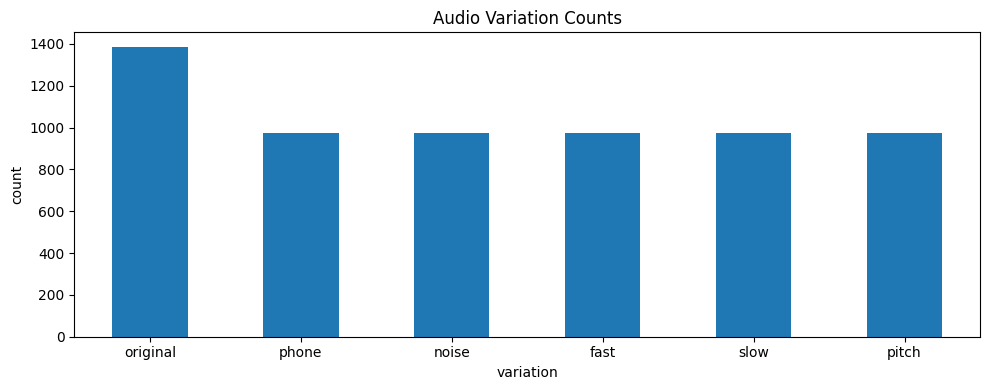

In [8]:
VARIATION_SUFFIXES = ['_phone', '_noise', '_fast', '_slow', '_pitch']


def detect_variation(file_name: str) -> str:
    stem = Path(file_name).stem
    for suffix in VARIATION_SUFFIXES:
        if stem.endswith(suffix):
            return suffix.replace('_', '')
    return 'original'


def base_key(file_name: str) -> str:
    stem = Path(file_name).stem
    for suffix in VARIATION_SUFFIXES:
        if stem.endswith(suffix):
            stem = stem[:-len(suffix)]
    return stem


def get_audio_meta(path: Path):
    try:
        with wave.open(str(path), 'rb') as wf:
            sr = wf.getframerate()
            n_frames = wf.getnframes()
            n_channels = wf.getnchannels()
            sample_width = wf.getsampwidth()
        return {
            'sample_rate': sr,
            'duration_sec': n_frames / sr if sr else np.nan,
            'channels': n_channels,
            'sample_width': sample_width,
        }
    except Exception as exc:
        return {
            'sample_rate': np.nan,
            'duration_sec': np.nan,
            'channels': np.nan,
            'sample_width': np.nan,
            'meta_error': str(exc),
        }


df = sample_submission[[ID_COL, 'audio_path']].copy()
df['variation'] = df[ID_COL].map(detect_variation)
df['base_key'] = df[ID_COL].map(base_key)
df['prefix'] = df[ID_COL].str.split('_').str[0]
df['file_size_mb'] = df['audio_path'].map(lambda p: Path(p).stat().st_size / 1024 / 1024)

meta_sample = df.sample(min(500, len(df)), random_state=SEED).copy()
meta_rows = []
for path in tqdm(meta_sample['audio_path'], desc='Reading audio metadata sample'):
    meta_rows.append(get_audio_meta(Path(path)))
meta_sample = pd.concat([meta_sample.reset_index(drop=True), pd.DataFrame(meta_rows)], axis=1)

print('Total rows:', len(df))
print('Unique base utterances:', df['base_key'].nunique())
print('Variation counts:')
display(df['variation'].value_counts().rename_axis('variation').reset_index(name='count'))
print('Prefix counts:')
display(df['prefix'].value_counts().rename_axis('prefix').reset_index(name='count'))
print('Group size counts:')
display(df.groupby('base_key').size().value_counts().sort_index().rename_axis('group_size').reset_index(name='n_groups'))
print('Audio metadata sample:')
display(meta_sample[['sample_rate', 'duration_sec', 'channels', 'sample_width', 'file_size_mb']].describe().round(3))

plt.figure(figsize=(10, 4))
df['variation'].value_counts().plot(kind='bar')
plt.title('Audio Variation Counts')
plt.xlabel('variation')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Data Loading & Initial Inspection
### 2.3 Preview a few audio files

Use this optional section to confirm that resolved audio paths are valid and the clips can be opened before starting full inference.

In [9]:
preview_rows = df.sample(min(3, len(df)), random_state=SEED).reset_index(drop=True)
display(preview_rows[[ID_COL, 'variation', 'base_key', 'audio_path']])

for _, row in preview_rows.iterrows():
    print(row[ID_COL], '|', row['variation'])
    display(Audio(filename=str(row['audio_path'])))

,file_name,variation,base_key,audio_path
0,INT_040_interrupt_pitch.wav,pitch,INT_040_interrupt,/root/.cache/kagglehub/competitions/individual...
1,SDB_158_turn_2_noise.wav,noise,SDB_158_turn_2,/root/.cache/kagglehub/competitions/individual...
2,SDB_100_turn_2_slow.wav,slow,SDB_100_turn_2,/root/.cache/kagglehub/competitions/individual...


INT_040_interrupt_pitch.wav | pitch


SDB_158_turn_2_noise.wav | noise


SDB_100_turn_2_slow.wav | slow


# 3. Data Preprocessing
### 3.1 Choose representative audio for each base utterance

Group augmented files that share the same transcript and select a representative clip for transcription.

In [10]:
PREFERRED_VARIATION_ORDER = ['original', 'slow', 'pitch', 'phone', 'fast', 'noise']


def choose_representative(group: pd.DataFrame) -> pd.Series:
    ranked = group.copy()
    ranked['variation_rank'] = ranked['variation'].map({v: i for i, v in enumerate(PREFERRED_VARIATION_ORDER)}).fillna(99)
    ranked = ranked.sort_values(['variation_rank', 'file_size_mb'], ascending=[True, False])
    return ranked.iloc[0]


representative_df = (
    df.groupby('base_key', group_keys=False)
      .apply(choose_representative)
      .reset_index(drop=True)
)
representative_df = representative_df[[ID_COL, 'base_key', 'variation', 'audio_path', 'file_size_mb']].copy()
representative_df = representative_df.rename(columns={ID_COL: 'representative_file_name', 'audio_path': 'representative_audio_path'})

print('Rows to submit:', len(df))
print('Representative rows to transcribe:', len(representative_df))
print('Reduction ratio:', round(len(representative_df) / len(df), 4))
display(representative_df.head(10))
display(representative_df['variation'].value_counts().rename_axis('chosen_variation').reset_index(name='count'))

Rows to submit: 6261
Representative rows to transcribe: 1386
Reduction ratio: 0.2214


,representative_file_name,base_key,variation,representative_audio_path,file_size_mb
0,AU_015a21ca-7e23-4b70-93e6-da8a1bb8eaab.wav,AU_015a21ca-7e23-4b70-93e6-da8a1bb8eaab,original,/root/.cache/kagglehub/competitions/individual...,1.652569
1,AU_02164b42-47ac-4d45-aa3a-0288ede4380e.wav,AU_02164b42-47ac-4d45-aa3a-0288ede4380e,original,/root/.cache/kagglehub/competitions/individual...,0.341839
2,AU_0225a06d-7949-49a6-84a0-0f4c2d9005aa.wav,AU_0225a06d-7949-49a6-84a0-0f4c2d9005aa,original,/root/.cache/kagglehub/competitions/individual...,0.927776
3,AU_02270177-6507-4730-b034-404aea8f8a5c.wav,AU_02270177-6507-4730-b034-404aea8f8a5c,original,/root/.cache/kagglehub/competitions/individual...,0.772137
4,AU_02c4081a-4df6-45bc-a24d-58efa0d70c1b.wav,AU_02c4081a-4df6-45bc-a24d-58efa0d70c1b,original,/root/.cache/kagglehub/competitions/individual...,1.269573
5,AU_03d93186-3c38-4e6e-925f-152d489ae8ef.wav,AU_03d93186-3c38-4e6e-925f-152d489ae8ef,original,/root/.cache/kagglehub/competitions/individual...,1.280254
6,AU_05d3d878-5ecf-4dd8-9663-ccfa7afaa9da.wav,AU_05d3d878-5ecf-4dd8-9663-ccfa7afaa9da,original,/root/.cache/kagglehub/competitions/individual...,1.126141
7,AU_0620b87a-52ed-46ea-b0bb-8d722b46e55a.wav,AU_0620b87a-52ed-46ea-b0bb-8d722b46e55a,original,/root/.cache/kagglehub/competitions/individual...,0.743145
8,AU_0731c90c-7376-45e2-9833-fc695f200585.wav,AU_0731c90c-7376-45e2-9833-fc695f200585,original,/root/.cache/kagglehub/competitions/individual...,2.101177
9,AU_07e19df7-fe34-497a-bb51-254c7570aac2.wav,AU_07e19df7-fe34-497a-bb51-254c7570aac2,original,/root/.cache/kagglehub/competitions/individual...,1.474041


,chosen_variation,count
0,original,1386


# 3. Data Preprocessing
### 3.2 Clean ASR text after decoding

Normalize the transcript, remove model artifacts, reduce repeated phrases, and apply call-center vocabulary corrections.

In [11]:
THAI_DIGIT_TABLE = str.maketrans('๐๑๒๓๔๕๖๗๘๙', '0123456789')

SPECIAL_TOKEN_PATTERNS = [
    r'<\|.*?\|>',
    r'\[.*?\]',
    r'\(.*?\)',
]

PUNCT_TO_SPACE = '"#$%&*+/:;<=>@[\\]^_`{|}~“”‘’—–…'
PUNCT_TO_REMOVE = ''.join(ch for ch in string.punctuation if ch not in ['-', '%'])
PUNCT_TRANSLATION = str.maketrans({ch: ' ' for ch in PUNCT_TO_SPACE + PUNCT_TO_REMOVE})

DOMAIN_REPLACEMENTS = {
    # เติมเองได้หลังดู error analysis เช่น 'เคดิต': 'เครดิต'
}


def clean_transcript(text: str) -> str:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ''
    s = unicodedata.normalize('NFC', str(text))
    for pattern in SPECIAL_TOKEN_PATTERNS:
        s = re.sub(pattern, ' ', s)
    s = s.translate(THAI_DIGIT_TABLE)
    s = s.translate(PUNCT_TRANSLATION)
    s = re.sub(r'\s+', ' ', s).strip()
    for wrong, right in DOMAIN_REPLACEMENTS.items():
        s = s.replace(wrong, right)
    return s


clean_examples = pd.DataFrame({
    'raw': [
        'สวัสดีค่ะ, พอดีจะสอบถามเรื่องบัตรเครดิตค่ะ',
        '<|th|> ผมทำบัตรเครดิตหายครับ ต้องการอายัดบัตรด่วน!',
        '[noise] เอ่อ คือว่า สมัครสินเชื่อได้ไหมครับ',
    ]
})
clean_examples['clean'] = clean_examples['raw'].map(clean_transcript)
display(clean_examples)

,raw,clean
0,"สวัสดีค่ะ, พอดีจะสอบถามเรื่องบัตรเครดิตค่ะ",สวัสดีค่ะ พอดีจะสอบถามเรื่องบัตรเครดิตค่ะ
1,<|th|> ผมทำบัตรเครดิตหายครับ ต้องการอายัดบัตรด...,ผมทำบัตรเครดิตหายครับ ต้องการอายัดบัตรด่วน
2,[noise] เอ่อ คือว่า สมัครสินเชื่อได้ไหมครับ,เอ่อ คือว่า สมัครสินเชื่อได้ไหมครับ


# 4. Model Preparation
### 4.1 Load the ASR model and processor

Prepare the speech-recognition model, decoding configuration, and fallback logic needed for robust inference.

In [12]:
def load_asr_pipeline(model_source: str = MODEL_SOURCE):
    import torch
    from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline

    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    device_index = 0 if torch.cuda.is_available() else -1
    torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

    print('Loading ASR model:', model_source)
    print('Device:', device)
    print('Torch dtype:', torch_dtype)

    try:
        model = AutoModelForSpeechSeq2Seq.from_pretrained(
            model_source,
            torch_dtype=torch_dtype,
            low_cpu_mem_usage=True,
            use_safetensors=True,
        )
    except Exception as exc:
        print('Load with safetensors failed, retry without forcing safetensors:', type(exc).__name__, exc)
        model = AutoModelForSpeechSeq2Seq.from_pretrained(
            model_source,
            torch_dtype=torch_dtype,
            low_cpu_mem_usage=True,
        )
    model.to(device)
    processor = AutoProcessor.from_pretrained(model_source)

    asr_pipe = pipeline(
        task='automatic-speech-recognition',
        model=model,
        tokenizer=processor.tokenizer,
        feature_extractor=processor.feature_extractor,
        torch_dtype=torch_dtype,
        device=device_index,
        chunk_length_s=30,
        batch_size=BATCH_SIZE,
    )
    return asr_pipe


GENERATE_KWARGS = {
    'language': 'thai',
    'task': 'transcribe',
    'num_beams': 10, # อัด num_beams เป็น 10 เพื่อให้โมเดลค้นหาคำตอบได้ดีขึ้น
}

print('ASR pipeline loader is ready.')

ASR pipeline loader is ready.


# 5. Model Inference
### 5.1 Transcribe representative audio files

Run transcription with caching so partial progress is preserved if the notebook is interrupted.

In [13]:
def load_prediction_cache(cache_path: Path) -> pd.DataFrame:
    if cache_path.exists():
        cache = pd.read_csv(cache_path, dtype=str)
        expected_cols = {'base_key', 'representative_file_name', 'raw_text', 'text'}
        missing_cols = expected_cols - set(cache.columns)
        if missing_cols:
            print('Ignore cache with missing columns:', missing_cols)
            return pd.DataFrame(columns=['base_key', 'representative_file_name', 'raw_text', 'text'])
        cache = cache.drop_duplicates('base_key', keep='last')
        print('Loaded cache:', cache_path, '| rows:', len(cache))
        return cache
    return pd.DataFrame(columns=['base_key', 'representative_file_name', 'raw_text', 'text'])


def save_prediction_cache(cache_df: pd.DataFrame, cache_path: Path):
    cache_df = cache_df.drop_duplicates('base_key', keep='last')
    cache_df.to_csv(cache_path, index=False)
    print('Saved cache:', cache_path, '| rows:', len(cache_df))


def run_asr_batches(asr_pipe, work_df: pd.DataFrame, cache_path: Path, limit=None) -> pd.DataFrame:
    cache_df = load_prediction_cache(cache_path)
    done_base_keys = set(cache_df['base_key'].astype(str)) if len(cache_df) else set()

    queue_df = work_df.copy()
    if limit is not None:
        queue_df = queue_df.head(limit)
    queue_df = queue_df[~queue_df['base_key'].astype(str).isin(done_base_keys)].reset_index(drop=True)

    print('Need to transcribe:', len(queue_df))
    if len(queue_df) == 0:
        return cache_df

    new_rows = []
    for start in tqdm(range(0, len(queue_df), BATCH_SIZE), desc='ASR inference'):
        batch = queue_df.iloc[start:start + BATCH_SIZE].copy()
        batch_paths = [str(Path(p)) for p in batch['representative_audio_path']]

        try:
            outputs = asr_pipe(
                batch_paths,
                generate_kwargs=GENERATE_KWARGS,
                return_timestamps=False,
            )
            if isinstance(outputs, dict):
                outputs = [outputs]
        except Exception as exc:
            print('Batch failed, retry file-by-file:', type(exc).__name__, exc)
            outputs = []
            for path in batch_paths:
                try:
                    outputs.append(asr_pipe(path, generate_kwargs=GENERATE_KWARGS, return_timestamps=False))
                except Exception as file_exc:
                    outputs.append({'text': '', 'error': f'{type(file_exc).__name__}: {file_exc}'})

        for (_, row), output in zip(batch.iterrows(), outputs):
            raw_text = output.get('text', '') if isinstance(output, dict) else str(output)
            clean_text = clean_transcript(raw_text)
            if clean_text == '':
                clean_text = DEFAULT_FALLBACK_TEXT
            new_rows.append({
                'base_key': row['base_key'],
                'representative_file_name': row['representative_file_name'],
                'raw_text': raw_text,
                'text': clean_text,
                'variation_used': row['variation'],
            })

        if len(new_rows) >= SAVE_EVERY:
            cache_df = pd.concat([cache_df, pd.DataFrame(new_rows)], ignore_index=True)
            save_prediction_cache(cache_df, cache_path)
            new_rows = []

    if new_rows:
        cache_df = pd.concat([cache_df, pd.DataFrame(new_rows)], ignore_index=True)
        save_prediction_cache(cache_df, cache_path)

    return cache_df


if RUN_ASR:
    try:
        asr_pipe = load_asr_pipeline(MODEL_SOURCE)
    except Exception as exc:
        print('Primary model failed:', type(exc).__name__, exc)
        print('Try fallback model:', FALLBACK_MODEL_NAME)
        asr_pipe = load_asr_pipeline(FALLBACK_MODEL_NAME)

    representative_predictions = run_asr_batches(
        asr_pipe,
        representative_df,
        REPRESENTATIVE_CACHE_PATH,
        limit=REPRESENTATIVE_LIMIT,
    )
else:
    print('RUN_ASR=False -> skip model loading. Use existing cache if available, otherwise create format-check submission only.')
    representative_predictions = load_prediction_cache(REPRESENTATIVE_CACHE_PATH)

print('Representative predictions:', representative_predictions.shape)
display(representative_predictions.head(10))

Loading ASR model: openai/whisper-large-v3
Device: cuda:0
Torch dtype: torch.float16


config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

...

[transformers] Passing `generation_config` together with generation-related arguments=({'num_beams'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <c

Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 32
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 64
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 96
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 128


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 160
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 192
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 224
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 256
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 288
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 320
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 352
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 384
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 416
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 448
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 480
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 512
Saved cache: /kaggle/working/asr_representative_predictions.csv | rows: 544
Saved cache:

,base_key,representative_file_name,raw_text,text,variation_used
0,AU_015a21ca-7e23-4b70-93e6-da8a1bb8eaab,AU_015a21ca-7e23-4b70-93e6-da8a1bb8eaab.wav,สวัสดีค่ะคุณเกศสุดาพร ดิฉันชื่อนางสาวนิธินาตมั...,สวัสดีค่ะคุณเกศสุดาพร ดิฉันชื่อนางสาวนิธินาตมั...,original
1,AU_02164b42-47ac-4d45-aa3a-0288ede4380e,AU_02164b42-47ac-4d45-aa3a-0288ede4380e.wav,ผมชื่อรัฐนะครับ วันนี้ขอเวลาสามสิบนาทีเพื่อพูด...,ผมชื่อรัฐนะครับ วันนี้ขอเวลาสามสิบนาทีเพื่อพูด...,original
2,AU_0225a06d-7949-49a6-84a0-0f4c2d9005aa,AU_0225a06d-7949-49a6-84a0-0f4c2d9005aa.wav,สวัสดีค่ะคุณปินติรา ดิฉันชื่อรชนิกรหรือเรียกว่...,สวัสดีค่ะคุณปินติรา ดิฉันชื่อรชนิกรหรือเรียกว่...,original
3,AU_02270177-6507-4730-b034-404aea8f8a5c,AU_02270177-6507-4730-b034-404aea8f8a5c.wav,ผมชื่อนายรัชวินภาวรการจัน หรือเรียกว่าวินก็ได้...,ผมชื่อนายรัชวินภาวรการจัน หรือเรียกว่าวินก็ได้...,original
4,AU_02c4081a-4df6-45bc-a24d-58efa0d70c1b,AU_02c4081a-4df6-45bc-a24d-58efa0d70c1b.wav,ผมชื่อปิดครับเป็นที่ปรึกษาทางการเงินจากธนาคารไ...,ผมชื่อปิดครับเป็นที่ปรึกษาทางการเงินจากธนาคารไ...,original
5,AU_03d93186-3c38-4e6e-925f-152d489ae8ef,AU_03d93186-3c38-4e6e-925f-152d489ae8ef.wav,ผม ทรัส เรียกสั้น ๆ ว่า ฉัน ก็ได้ครับเป็นที่ปร...,ผม ทรัส เรียกสั้น ๆ ว่า ฉัน ก็ได้ครับเป็นที่ปร...,original
6,AU_05d3d878-5ecf-4dd8-9663-ccfa7afaa9da,AU_05d3d878-5ecf-4dd8-9663-ccfa7afaa9da.wav,ดิฉันชื่อพิชชาค่ะ จากธนาคารไทยพาณิชย์ได้รับมอบ...,ดิฉันชื่อพิชชาค่ะ จากธนาคารไทยพาณิชย์ได้รับมอบ...,original
7,AU_0620b87a-52ed-46ea-b0bb-8d722b46e55a,AU_0620b87a-52ed-46ea-b0bb-8d722b46e55a.wav,สวัสดีครับคุณที่พนัน ผมพัฒนศักดิ์ครับหรือเรียก...,สวัสดีครับคุณที่พนัน ผมพัฒนศักดิ์ครับหรือเรียก...,original
8,AU_0731c90c-7376-45e2-9833-fc695f200585,AU_0731c90c-7376-45e2-9833-fc695f200585.wav,สวัสดีค่ะคุณนัทริกา ดิฉันชื่อเตชินีหรือเรียกว่...,สวัสดีค่ะคุณนัทริกา ดิฉันชื่อเตชินีหรือเรียกว่...,original
9,AU_07e19df7-fe34-497a-bb51-254c7570aac2,AU_07e19df7-fe34-497a-bb51-254c7570aac2.wav,ผมวรชัยกริมกุลครับ เรียกผมว่าต้นก็ได้ผมเป็นที่...,ผมวรชัยกริมกุลครับ เรียกผมว่าต้นก็ได้ผมเป็นที่...,original


# 6. Prediction & Submission Generation
### 6.1 Expand predictions back to all rows

Map each representative transcript back to every matching sample-submission row while preserving the original order.

In [14]:
prediction_map = representative_predictions[['base_key', 'text']].drop_duplicates('base_key', keep='last') if len(representative_predictions) else pd.DataFrame(columns=['base_key', 'text'])
full_prediction_df = df[[ID_COL, 'base_key', 'variation', 'audio_path']].merge(prediction_map, on='base_key', how='left')
missing_prediction_count = full_prediction_df['text'].isna().sum()

if missing_prediction_count > 0:
    print('Missing prediction rows:', missing_prediction_count)
    print('Missing base groups:', full_prediction_df.loc[full_prediction_df['text'].isna(), 'base_key'].nunique())
    full_prediction_df['text'] = full_prediction_df['text'].fillna(DEFAULT_FALLBACK_TEXT)
else:
    print('All rows have prediction.')

full_prediction_df['text'] = full_prediction_df['text'].map(clean_transcript)
full_prediction_df.loc[full_prediction_df['text'].str.len() == 0, 'text'] = DEFAULT_FALLBACK_TEXT

if RUN_ASR and len(representative_predictions) > 0:
    full_prediction_df.to_csv(FULL_PREDICTION_CACHE_PATH, index=False)
    print('Full prediction cache saved:', FULL_PREDICTION_CACHE_PATH)
else:
    print('Skip full prediction cache because this is a format-only smoke test or no ASR prediction is available yet.')

print('Full prediction table:', full_prediction_df.shape)
display(full_prediction_df.head(10))
display(full_prediction_df['variation'].value_counts().rename_axis('variation').reset_index(name='count'))

All rows have prediction.
Full prediction cache saved: /kaggle/working/asr_full_predictions.csv
Full prediction table: (6261, 5)


,file_name,base_key,variation,audio_path,text
0,RSP_101_audio.wav,RSP_101_audio,original,/root/.cache/kagglehub/competitions/individual...,ช่วยร่าง Script โทรนัดดูห้องเช่าหน่อยถามข้อมูล...
1,RSP_106_audio.wav,RSP_106_audio,original,/root/.cache/kagglehub/competitions/individual...,ช่วยวางแผนการทดลองง่าย ๆ ที่บ้านให้เด็กเข้าใจเ...
2,RSP_108_audio.wav,RSP_108_audio,original,/root/.cache/kagglehub/competitions/individual...,วิเคราะห์ปัจจัยสำคัญที่ทำให้กรุงศรีอยุธยา รุ่ง...
3,RSP_109_audio.wav,RSP_109_audio,original,/root/.cache/kagglehub/competitions/individual...,ถ้าจะพิมพ์ชิ้นส่วนที่ต้องทนแรงกระแทก ควรเลือกใ...
4,RSP_107_audio.wav,RSP_107_audio,original,/root/.cache/kagglehub/competitions/individual...,ทฤษฎี Big Bang กับทฤษฎีสภาวะคมที่อันไหนน่าเชื่...
5,RSP_100_audio.wav,RSP_100_audio,original,/root/.cache/kagglehub/competitions/individual...,ใบขับขี่ผมจะหมดอายุอีก 6 เดือน แต่ต้องไปต่างปร...
6,RSP_072_audio.wav,RSP_072_audio,original,/root/.cache/kagglehub/competitions/individual...,ช่วยวางแผนต่อรองราคารถหน่อยครับ สมมุติเต็นตั้ง...
7,RSP_086_audio.wav,RSP_086_audio,original,/root/.cache/kagglehub/competitions/individual...,อยากชวนเพื่อนไปดูงานสินวันเสาร์บ่ายช่วยแนะนำที...
8,RSP_081_audio.wav,RSP_081_audio,original,/root/.cache/kagglehub/competitions/individual...,จากฟอร์มเมื่อคืนช่วยวิเคราะห์หน่อยสิว่า แท็กติ...
9,RSP_075_audio.wav,RSP_075_audio,original,/root/.cache/kagglehub/competitions/individual...,ถ้าจะคุยเรื่องวัฒนธรรมไทยกับเพื่อนต่างชาติควรเ...


,variation,count
0,original,1386
1,phone,975
2,noise,975
3,fast,975
4,slow,975
5,pitch,975


# 6. Prediction & Submission Generation
### 6.2 Write the final submission file

Create the final CSV with the exact columns expected by the competition and save it to the working directory.

In [15]:
prediction_for_submit = full_prediction_df[[ID_COL, 'text']].rename(columns={'text': 'prediction_text'})
submission = sample_submission[[ID_COL]].copy().merge(
    prediction_for_submit,
    on=ID_COL,
    how='left',
)
submission[TEXT_COL] = submission['prediction_text'].fillna(DEFAULT_FALLBACK_TEXT).astype(str).map(clean_transcript)
submission.loc[submission[TEXT_COL].str.len() == 0, TEXT_COL] = DEFAULT_FALLBACK_TEXT
submission = submission.drop(columns=['prediction_text'])
submission = submission[[ID_COL, TEXT_COL]]

output_path = SUBMISSION_PATH if RUN_ASR else FORMAT_CHECK_SUBMISSION_PATH
submission.to_csv(output_path, index=False)

print('Submission saved:', output_path)
print('Submission shape:', submission.shape)
display(submission.head(10))

Submission saved: /kaggle/working/submission.csv
Submission shape: (6261, 2)


,file_name,text
0,RSP_101_audio.wav,ช่วยร่าง Script โทรนัดดูห้องเช่าหน่อยถามข้อมูล...
1,RSP_106_audio.wav,ช่วยวางแผนการทดลองง่าย ๆ ที่บ้านให้เด็กเข้าใจเ...
2,RSP_108_audio.wav,วิเคราะห์ปัจจัยสำคัญที่ทำให้กรุงศรีอยุธยา รุ่ง...
3,RSP_109_audio.wav,ถ้าจะพิมพ์ชิ้นส่วนที่ต้องทนแรงกระแทก ควรเลือกใ...
4,RSP_107_audio.wav,ทฤษฎี Big Bang กับทฤษฎีสภาวะคมที่อันไหนน่าเชื่...
5,RSP_100_audio.wav,ใบขับขี่ผมจะหมดอายุอีก 6 เดือน แต่ต้องไปต่างปร...
6,RSP_072_audio.wav,ช่วยวางแผนต่อรองราคารถหน่อยครับ สมมุติเต็นตั้ง...
7,RSP_086_audio.wav,อยากชวนเพื่อนไปดูงานสินวันเสาร์บ่ายช่วยแนะนำที...
8,RSP_081_audio.wav,จากฟอร์มเมื่อคืนช่วยวิเคราะห์หน่อยสิว่า แท็กติ...
9,RSP_075_audio.wav,ถ้าจะคุยเรื่องวัฒนธรรมไทยกับเพื่อนต่างชาติควรเ...


# 6. Prediction & Submission Generation
### 6.3 Run submission safety checks

Check row count, missing values, duplicated ids, and transcript length before uploading the result.

In [16]:
safety_report = {
    'columns_match_sample': list(submission.columns) == [ID_COL, TEXT_COL],
    'row_count_matches_sample': len(submission) == len(sample_submission),
    'ids_match_sample_order': submission[ID_COL].tolist() == sample_submission[ID_COL].tolist(),
    'no_duplicate_ids': submission[ID_COL].duplicated().sum() == 0,
    'no_missing_text': submission[TEXT_COL].isna().sum() == 0,
    'no_empty_text': bool((submission[TEXT_COL].astype(str).str.len() > 0).all()),
    'audio_rows_all_resolved': sample_submission['audio_path'].isna().sum() == 0,
    'no_hosted_inference_api_used': True,
}

safety_df = pd.DataFrame([safety_report]).T.rename(columns={0: 'status'})
display(safety_df)

if all(bool(value) for value in safety_report.values()):
    print('Submit safety checks passed.')
else:
    print('Please inspect failed safety checks before submitting.')

,status
columns_match_sample,True
row_count_matches_sample,True
ids_match_sample_order,True
no_duplicate_ids,True
no_missing_text,True
no_empty_text,True
audio_rows_all_resolved,True
no_hosted_inference_api_used,True


Submit safety checks passed.
